# Production Economy: Eggertsson & Mehrotra (2014) + Lu (2015)

This notebook replicates the New Keynesian production economy results from:

- **Eggertsson & Mehrotra (2014)** "A Model of Secular Stagnation", sections 4–6  
- **Lu (2015)** "Bubbles in a Secular Stagnation Economy", section 3

The steady state is characterised by aggregate supply (AS) and aggregate demand (AD)
curves in $(Y, \Pi)$ space, each with two regimes.

Sections:
1. [Setup](#1-Setup)
2. [Sanity Checks](#2-Sanity-Checks)
3. [AS/AD — Normal Equilibrium (EM Figure 2)](#3-AS/AD-Normal-Equilibrium)
4. [AS/AD — Secular Stagnation (EM Figure 3)](#4-AS/AD-Secular-Stagnation)
5. [Bubble Effect on AS/AD (Lu 2015 Figure 3)](#5-Bubble-Effect-on-AS/AD)

---
## 1  Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import src.calibration as cal

from src.production_model import (
    potential_output,
    aggregate_supply,
    aggregate_demand,
    pi_kink,
    find_equilibrium,
    natural_rate_production,
)
from src.endowment_model import bubble_upper_bound, fundamental_rate

FIG_DIR = os.path.join(os.path.dirname(os.getcwd()), 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

# Convenience aliases
BETA    = cal.BETA
D_H     = cal.D
D_L     = cal.D_L
G       = cal.G
ALPHA   = cal.ALPHA
L_BAR   = cal.L_BAR
GAMMA   = cal.GAMMA
PHI_PI  = cal.PHI_PI
PI_STAR = cal.PI_STAR
I_STAR  = cal.I_STAR

# Derived constants used across sections
Y_F    = potential_output(L_BAR, ALPHA)
PI_K   = pi_kink(I_STAR, PHI_PI, PI_STAR)
A_MAX  = bubble_upper_bound(Y_F, D_L, BETA)  # max bubble at D_L

# Pi grid for plotting: covers both ZLB and normal regimes
PI_GRID = np.linspace(0.80, 1.25, 600)

print(f'Y_f = {Y_F:.4f},  Pi_kink = {PI_K:.4f},  A_max (D_L) = {A_MAX:.4f}')

Y_f = 1.0000,  Pi_kink = 1.0100,  A_max (D_L) = 0.0634


---
## 2  Sanity Checks

In [2]:
print('='*60)
for D, label in [(D_H, 'D_H (pre-shock)'), (D_L, 'D_L (post-deleveraging)')]:
    eq = find_equilibrium(D, G, BETA, PHI_PI, PI_STAR, I_STAR,
                          GAMMA, ALPHA, L_BAR)
    Rn = natural_rate_production(D, G, Y_F, BETA)
    print(f'\n{label}')
    print(f'  Potential output Y_f : {Y_F:.4f}')
    print(f'  Pi_kink              : {PI_K:.4f}')
    print(f'  Natural rate R^n     : {Rn:.4f}  (r^n = {Rn-1:.4f})')
    print(f'  Equilibrium Y        : {eq["Y"]:.4f}')
    print(f'  Equilibrium Pi       : {eq["Pi"]:.4f}')
    print(f'  Regime               : {eq["regime"]}')
    print(f'  i_nominal            : {eq["i_nominal"]:.4f}')
print('='*60)

eq_H = find_equilibrium(D_H, G, BETA, PHI_PI, PI_STAR, I_STAR, GAMMA, ALPHA, L_BAR)
eq_L = find_equilibrium(D_L, G, BETA, PHI_PI, PI_STAR, I_STAR, GAMMA, ALPHA, L_BAR)
assert eq_H['regime'] == 'normal', 'D_H should give normal regime'
assert eq_L['regime'] == 'zlb',    'D_L should give ZLB regime'
print('\nRegime assertions passed.')

# --- D_H cross-check at Pi = Pi_star = 1.01 --------------------------------
print('\n' + '-'*60)
print(f'D = D_H: curve values at Pi = Pi_star = {PI_STAR}')
AS_at_pistar = float(aggregate_supply(PI_STAR, Y_F, GAMMA, ALPHA))
AD_at_pistar = float(aggregate_demand(PI_STAR, D_H, G, BETA, PHI_PI, PI_STAR, I_STAR))
print(f'  AS(Pi_star) = {AS_at_pistar:.4f}  (= Y_f = {Y_F:.4f} since Pi_star >= 1)')
print(f'  AD(Pi_star) = {AD_at_pistar:.4f}')
print(f'  AD - AS     = {AD_at_pistar - AS_at_pistar:+.4f}')
print(f'  (positive => AD > AS at target, so equilibrium Pi > Pi_star, as in EM Fig 2)')
print('-'*60)


D_H (pre-shock)
  Potential output Y_f : 1.0000
  Pi_kink              : 1.0100
  Natural rate R^n     : 1.0727  (r^n = 0.0727)
  Equilibrium Y        : 1.0000
  Equilibrium Pi       : 1.0943
  Regime               : normal
  i_nominal            : 0.1739

D_L (post-deleveraging)
  Potential output Y_f : 1.0000
  Pi_kink              : 1.0100
  Natural rate R^n     : 0.9642  (r^n = -0.0358)
  Equilibrium Y        : 0.9182
  Equilibrium Pi       : 0.9227
  Regime               : zlb
  i_nominal            : 0.0000

Regime assertions passed.

------------------------------------------------------------
D = D_H: curve values at Pi = Pi_star = 1.01
  AS(Pi_star) = 1.0000  (= Y_f = 1.0000 since Pi_star >= 1)
  AD(Pi_star) = 1.0601
  AD - AS     = +0.0601
  (positive => AD > AS at target, so equilibrium Pi > Pi_star, as in EM Fig 2)
------------------------------------------------------------


---
## 3  AS/AD — Normal Equilibrium

Replicates **EM (2014) Figure 2**.  
Pre-shock economy with $D = D_H$.  The Taylor rule is active and the
equilibrium is at full employment (point A).

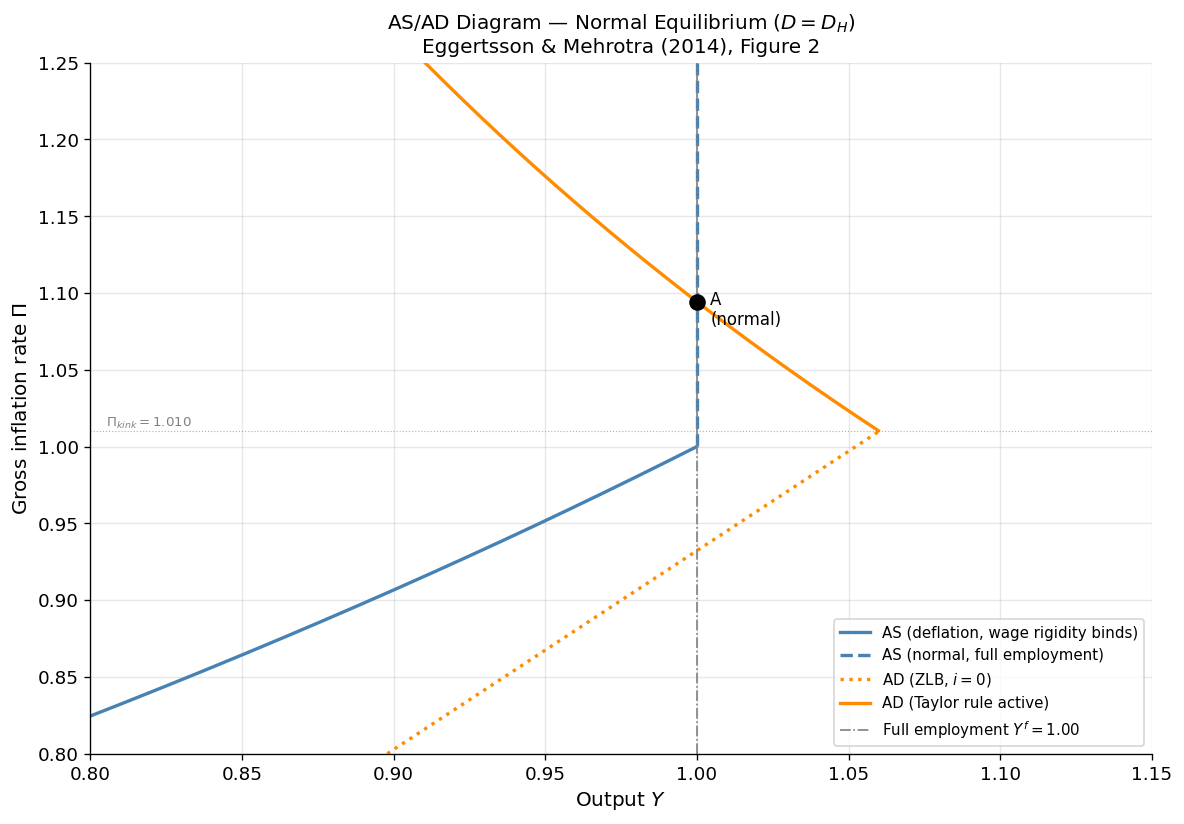

Saved: figures/fig3_asad_normal.{pdf,png}


In [3]:
# Curves — Y on x-axis, Pi on y-axis
AS_vals  = aggregate_supply(PI_GRID, Y_F, GAMMA, ALPHA)
AD_H_vals = aggregate_demand(PI_GRID, D_H, G, BETA, PHI_PI, PI_STAR, I_STAR)

# Equilibrium point A
Y_A, Pi_A = eq_H['Y'], eq_H['Pi']

fig, ax = plt.subplots(figsize=(10, 7))

# AS: two segments — deflation (Pi<1) and normal (Pi>=1)
mask_as_def  = PI_GRID < 1.0
mask_as_norm = PI_GRID >= 1.0
ax.plot(AS_vals[mask_as_def],  PI_GRID[mask_as_def],
        color='steelblue', lw=2, label='AS (deflation, wage rigidity binds)')
ax.plot(AS_vals[mask_as_norm], PI_GRID[mask_as_norm],
        color='steelblue', lw=2, ls='--', label='AS (normal, full employment)')

# AD: two segments — ZLB (Pi < Pi_kink) and Taylor rule (Pi >= Pi_kink)
mask_ad_zlb  = PI_GRID < PI_K
mask_ad_norm = PI_GRID >= PI_K
ax.plot(AD_H_vals[mask_ad_zlb],  PI_GRID[mask_ad_zlb],
        color='darkorange', lw=2, ls=':', label='AD (ZLB, $i=0$)')
ax.plot(AD_H_vals[mask_ad_norm], PI_GRID[mask_ad_norm],
        color='darkorange', lw=2, label='AD (Taylor rule active)')

# Full employment vertical line
ax.axvline(Y_F, color='grey', lw=1.0, ls='-.', label=f'Full employment $Y^f={Y_F:.2f}$')

# ZLB kink horizontal marker
ax.axhline(PI_K, color='grey', lw=0.7, ls=':', alpha=0.6)
ax.text(0.805, PI_K + 0.003, f'$\\Pi_{{kink}}={PI_K:.3f}$', fontsize=8, color='grey')

# Equilibrium point A
ax.scatter([Y_A], [Pi_A], color='black', zorder=6, s=80)
ax.annotate('A\n(normal)', (Y_A, Pi_A),
            textcoords='offset points', xytext=(8, -14),
            fontsize=10, color='black')

ax.set_xlim(0.80, 1.15)
ax.set_ylim(0.80, 1.25)
ax.set_xlabel('Output $Y$', fontsize=12)
ax.set_ylabel('Gross inflation rate $\\Pi$', fontsize=12)
ax.set_title('AS/AD Diagram — Normal Equilibrium ($D = D_H$)\n'
             'Eggertsson & Mehrotra (2014), Figure 2', fontsize=12)
ax.legend(fontsize=9, loc='lower right')

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig3_asad_normal.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'fig3_asad_normal.png'), bbox_inches='tight')
plt.show()
print('Saved: figures/fig3_asad_normal.{pdf,png}')

---
## 4  AS/AD — Secular Stagnation

Replicates **EM (2014) Figure 3**.  
The deleveraging shock tightens the collateral constraint from $D_H$ to $D_L$,
shifting AD inward.  The new equilibrium (B) is in the ZLB regime with
output below potential — secular stagnation.

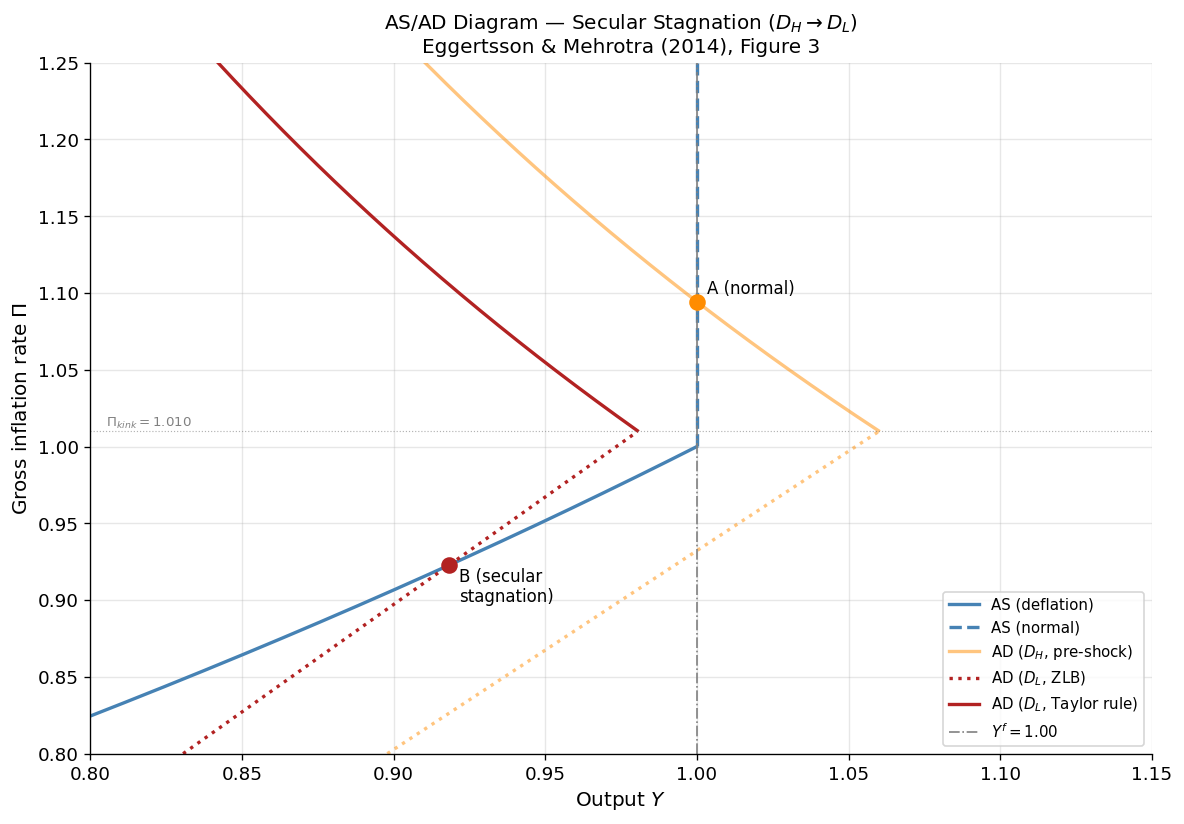

Saved: figures/fig4_asad_stagnation.{pdf,png}


In [4]:
AD_L_vals = aggregate_demand(PI_GRID, D_L, G, BETA, PHI_PI, PI_STAR, I_STAR)

# Equilibrium points
Y_A, Pi_A = eq_H['Y'], eq_H['Pi']
Y_B, Pi_B = eq_L['Y'], eq_L['Pi']

fig, ax = plt.subplots(figsize=(10, 7))

# AS (same in both regimes)
ax.plot(AS_vals[mask_as_def],  PI_GRID[mask_as_def],
        color='steelblue', lw=2, label='AS (deflation)')
ax.plot(AS_vals[mask_as_norm], PI_GRID[mask_as_norm],
        color='steelblue', lw=2, ls='--', label='AS (normal)')

# AD — D_H (pre-shock)
ax.plot(AD_H_vals[mask_ad_zlb],  PI_GRID[mask_ad_zlb],
        color='darkorange', lw=2, ls=':', alpha=0.5)
ax.plot(AD_H_vals[mask_ad_norm], PI_GRID[mask_ad_norm],
        color='darkorange', lw=2, alpha=0.5, label='AD ($D_H$, pre-shock)')

# AD — D_L (post-shock)
ax.plot(AD_L_vals[mask_ad_zlb],  PI_GRID[mask_ad_zlb],
        color='firebrick', lw=2, ls=':', label='AD ($D_L$, ZLB)')
ax.plot(AD_L_vals[mask_ad_norm], PI_GRID[mask_ad_norm],
        color='firebrick', lw=2, label='AD ($D_L$, Taylor rule)')

# Full employment line
ax.axvline(Y_F, color='grey', lw=1.0, ls='-.', label=f'$Y^f = {Y_F:.2f}$')

# ZLB kink
ax.axhline(PI_K, color='grey', lw=0.7, ls=':', alpha=0.6)
ax.text(0.805, PI_K + 0.003, f'$\\Pi_{{kink}}={PI_K:.3f}$', fontsize=8, color='grey')

# Equilibrium dots
ax.scatter([Y_A], [Pi_A], color='darkorange', zorder=6, s=80)
ax.annotate('A (normal)', (Y_A, Pi_A),
            textcoords='offset points', xytext=(6, 5), fontsize=10)

ax.scatter([Y_B], [Pi_B], color='firebrick', zorder=6, s=80)
ax.annotate('B (secular\nstagnation)', (Y_B, Pi_B),
            textcoords='offset points', xytext=(6, -22), fontsize=10)

ax.set_xlim(0.80, 1.15)
ax.set_ylim(0.80, 1.25)
ax.set_xlabel('Output $Y$', fontsize=12)
ax.set_ylabel('Gross inflation rate $\\Pi$', fontsize=12)
ax.set_title('AS/AD Diagram — Secular Stagnation ($D_H \\to D_L$)\n'
             'Eggertsson & Mehrotra (2014), Figure 3', fontsize=12)
ax.legend(fontsize=9, loc='lower right')

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig4_asad_stagnation.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'fig4_asad_stagnation.png'), bbox_inches='tight')
plt.show()
print('Saved: figures/fig4_asad_stagnation.{pdf,png}')

---
## 5  Bubble Effect on AS/AD

Replicates **Lu (2015) Figure 3**.  
$D = D_L$ is held fixed.  A rational bubble of size $A$ enters
households' portfolios, shifting AD **rightward** by raising aggregate
demand at every inflation rate.  Even a bubble of $A = A_{\max}/2$
suffices to restore full employment.

## Bubbles and the Escape from Secular Stagnation

The fundamental economy ($A=0$) is stuck in secular stagnation:
the natural rate of interest is negative, the ZLB binds, and
output falls permanently below potential (point B).

A rational bubble changes this by absorbing excess savings.
This raises the natural rate of interest, which shifts the
entire AD curve rightward — both the ZLB segment and the
Taylor rule segment. The kink point moves outward along the
$\Pi_{kink}$ line.

The diagram below shows three steady-state AD curves for
increasing bubble sizes $A = 0$, $A_{\max}/2$, and $A_{\max}$,
holding $D = D_L$ fixed:

- **Point B** ($A=0$): secular stagnation equilibrium. Output
  gap is permanent, deflation persists, ZLB binds indefinitely.
- **Intermediate** ($A=A_{\max}/2$): bubble partially absorbs excess
  savings. Output gap narrows but full employment is not restored.
- **Point C** ($A=A_{\max}$): bubble fully eliminates secular
  stagnation. The AD curve has shifted far enough right that
  it intersects AS at full employment $Y=1$.

The key mechanism: the bubble does not directly produce output.
It acts purely through the loan market — by absorbing savings
that would otherwise depress the natural rate, it raises the
natural rate above the ZLB threshold and allows the economy to
reach full employment.

However, this solution is fragile. A bubble large enough to
restore full employment is by construction close to its upper
bound and therefore more likely to collapse. The collapse of
the bubble reverses the AD shift, potentially triggering
secular stagnation — exactly the mechanism proposed in
Lu (2015) to explain the role of the 2007 housing bubble
collapse.

A_max (at D_L = 0.259) = 0.0634


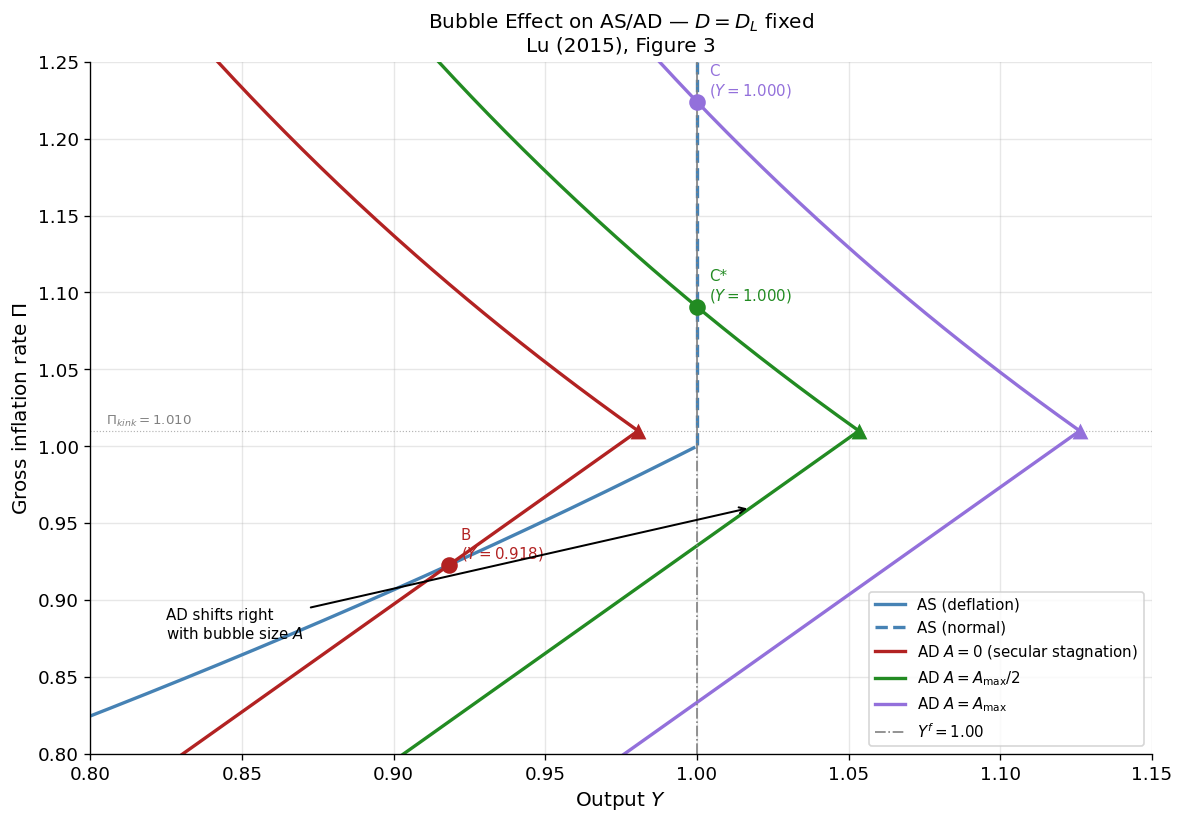

Saved: figures/fig5_asad_bubble.{pdf,png}


In [5]:
print(f'A_max (at D_L = {D_L}) = {A_MAX:.4f}')

bubble_cases = [
    (0.0,          'firebrick',    'B',  '$A = 0$ (secular stagnation)'),
    (A_MAX * 0.5,  'forestgreen',  'C*', r'$A = A_{\max}/2$'),
    (A_MAX,        'mediumpurple', 'C',  r'$A = A_{\max}$'),
]

# Single Pi grid covering both ZLB and Taylor-rule regimes
Pi_grid = np.linspace(GAMMA + 0.001, 1.25, 500)

fig, ax = plt.subplots(figsize=(10, 7))

# --- AS ---
AS_vals_bubble = aggregate_supply(Pi_grid, Y_F, GAMMA, ALPHA)
mask_def  = Pi_grid < 1.0
mask_norm = Pi_grid >= 1.0
ax.plot(AS_vals_bubble[mask_def],  Pi_grid[mask_def],
        color='steelblue', lw=2,      label='AS (deflation)')
ax.plot(AS_vals_bubble[mask_norm], Pi_grid[mask_norm],
        color='steelblue', lw=2, ls='--', label='AS (normal)')

# --- AD curves: one per bubble size, delegate regime logic to aggregate_demand ---
for A, color, point_label, legend_label in bubble_cases:
    Y_ad = np.array([aggregate_demand(pi, D_L, G, BETA, PHI_PI, PI_STAR, I_STAR,
                                      A_bubble=A) for pi in Pi_grid])
    ax.plot(Y_ad, Pi_grid, color=color, lw=2, label=f'AD {legend_label}')

    # Triangle marker at Pi_kink (kink location in Pi is identical across bubble sizes)
    Y_kink = aggregate_demand(PI_K, D_L, G, BETA, PHI_PI, PI_STAR, I_STAR, A_bubble=A)
    ax.scatter([Y_kink], [PI_K], color=color, marker='^', zorder=7, s=90, linewidths=0)

    # Equilibrium dot
    eq_b = find_equilibrium(D_L, G, BETA, PHI_PI, PI_STAR, I_STAR,
                            GAMMA, ALPHA, L_BAR, A_bubble=A)
    Y_eq, Pi_eq = eq_b['Y'], eq_b['Pi']
    ax.scatter([Y_eq], [Pi_eq], color=color, zorder=6, s=80)
    ax.annotate(f'{point_label}\n($Y={Y_eq:.3f}$)', (Y_eq, Pi_eq),
                textcoords='offset points', xytext=(7, 4),
                fontsize=9, color=color)

# --- Annotation arrow (tip computed via aggregate_demand, not manually) ---
Y_arrow = aggregate_demand(0.96, D_L, G, BETA, PHI_PI, PI_STAR, I_STAR,
                           A_bubble=A_MAX * 0.5)
ax.annotate('AD shifts right\nwith bubble size $A$',
            xy=(Y_arrow, 0.96),
            xytext=(0.825, 0.875),
            fontsize=9, color='black',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
            ha='left')

# Full employment line
ax.axvline(Y_F, color='grey', lw=1.0, ls='-.', label=f'$Y^f = {Y_F:.2f}$')

# ZLB kink reference line
ax.axhline(PI_K, color='grey', lw=0.7, ls=':', alpha=0.6)
ax.text(0.805, PI_K + 0.004, f'$\\Pi_{{kink}}={PI_K:.3f}$', fontsize=8, color='grey')

ax.set_xlim(0.80, 1.15)
ax.set_ylim(0.80, 1.25)
ax.set_xlabel('Output $Y$', fontsize=12)
ax.set_ylabel('Gross inflation rate $\\Pi$', fontsize=12)
ax.set_title('Bubble Effect on AS/AD — $D = D_L$ fixed\n'
             'Lu (2015), Figure 3', fontsize=12)
ax.legend(fontsize=9, loc='lower right')

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig5_asad_bubble.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'fig5_asad_bubble.png'), bbox_inches='tight')
plt.show()
print('Saved: figures/fig5_asad_bubble.{pdf,png}')

**Figure note:** The three AD curves correspond to bubble sizes
$A = 0$ (fundamental economy), $A = A_{\max}/2$, and $A = A_{\max}$.
The AS curve and the full employment line $Y^f = 1$ are fixed.
A larger bubble shifts AD rightward in both regimes, moving the
equilibrium from secular stagnation (point B, $Y=0.918$) toward
and eventually to full employment (point C, $Y=1.0$). All curves
are computed using the EM (2014) baseline calibration with
$D = D_L = 0.259$ and the Lu (2015) bubble extension.